### Define Target Variable & Features
In this cell, we define the target variable (Is_Churn: 1 for inactive customers > 90 days, 0 for active) and extract the input features:

In [2]:
import numpy as np
import pandas as pd
from scipy import stats

file_path = r"C:\Users\SKHAKH MUBASHSHIR\data.csv"

# CSV File load
df = pd.read_csv(file_path,encoding='latin-1')

#  preview check 
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:

# Ensure InvoiceDate & TotalRevenue are processed
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
if "TotalRevenue" not in df.columns:
    df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

# Clean missing Customer IDs and calculate snapshot date
df_clean = df.dropna(subset=["CustomerID", "InvoiceDate"]).copy()
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Aggregate customer-level feature metrics
model_df = (
    df_clean.groupby("CustomerID")
    .agg(
        {
            "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
            "InvoiceNo": "nunique",  # Frequency
            "TotalRevenue": lambda x: x.clip(lower=0).sum(),  # Monetary Spend
            "Quantity": "mean",  # Avg Quantity per order item
            "UnitPrice": "mean",  # Avg Unit Price per order item
        }
    )
    .reset_index()
)

model_df.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Quantity",
    "Avg_UnitPrice",
]

#  Target Variable Definition (Churn = 1 if Recency > 90 days, else 0)
churn_threshold = 90
model_df["Is_Churn"] = (model_df["Recency"] > churn_threshold).astype(int)

# Separate input features (X) and target variable (y)
X = model_df[
    ["Frequency", "Monetary", "Avg_Quantity", "Avg_UnitPrice"]
].copy()
y = model_df["Is_Churn"]

print("Target Variable & Features Defined.")
print("\nClass Distribution (0 = Active, 1 = Churned):")
print(y.value_counts())

Target Variable & Features Defined.

Class Distribution (0 = Active, 1 = Churned):
Is_Churn
0    2918
1    1454
Name: count, dtype: int64


### Split Data into Train/Test (80/20)
In this cell, we perform an 80/20 train-test split and apply feature scaling using StandardScaler:

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#  Train/Test Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split & Scaled Successfully.")
print(f"Training Set Shape : {X_train_scaled.shape}")
print(f"Testing Set Shape  : {X_test_scaled.shape}")

Data Split & Scaled Successfully.
Training Set Shape : (3497, 4)
Testing Set Shape  : (875, 4)


### Build Model (Logistic Regression)
In this cell, we train a Logistic Regression model on the scaled training dataset:

In [7]:
from sklearn.linear_model import LogisticRegression

#  Build & Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on Test Data
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [7]:
from sklearn.linear_model import LogisticRegression

#  Build & Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on Test Data
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


### Evaluate Model (Accuracy, Precision, Recall, Confusion Matrix)
In this cell, we evaluate the classification performance and plot the Confusion Matrix:

             LOGISTIC REGRESSION EVALUATION             
Accuracy  : 70.74%
Precision : 0.5651
Recall    : 0.5223
F1-Score  : 0.5429


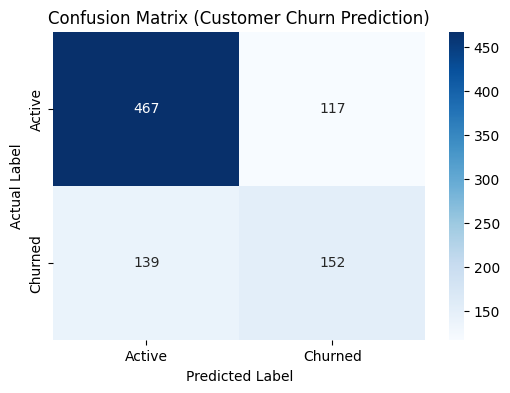

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Model Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 55)
print("             LOGISTIC REGRESSION EVALUATION             ")
print("=" * 55)
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=" * 55)

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Active", "Churned"],
    yticklabels=["Active", "Churned"],
)
plt.title("Confusion Matrix (Customer Churn Prediction)", fontsize=12)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()